<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Exercises/Module_4_Decision-tree/2a_Fires.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In the code cell below import the following
- pandas as __pd__
- numpy as __np__
- matplotlib.pyplot as __plt__
- seaborn as __sns__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Activity 1


Write code to perform following:
1. Read in the dataset on AWS at [Brazilian-fire-dataset.csv]( https://ddc-datascience.s3.amazonaws.com/Brazilian-fire-dataset.csv ) and assign it to a variable called `df_ffire`.
1. Display the top 10 rows of the data frame.
1. Generate summary statistics for all columns.

In [2]:
url = "https://ddc-datascience.s3.amazonaws.com/Brazilian-fire-dataset.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Brazilian-fire-dataset.csv'

In [3]:
df_ffire = pd.read_csv(url)

In [4]:
df_ffire.head(10)

,Year,State,Month,Number of Fires,Date Reported
0,1998,Acre,January,0.0,1/01/1998
1,1999,Acre,January,0.0,1/01/1999
2,2000,Acre,January,0.0,1/01/2000
3,2001,Acre,January,0.0,1/01/2001
4,2002,Acre,January,0.0,1/01/2002
5,2003,Acre,January,10.0,1/01/2003
6,2004,Acre,January,0.0,1/01/2004
7,2005,Acre,January,12.0,1/01/2005
8,2006,Acre,January,4.0,1/01/2006
9,2007,Acre,January,0.0,1/01/2007


In [5]:
df_ffire.shape

(6454, 5)

In [6]:
df_ffire.describe(include='all')

,Year,State,Month,Number of Fires,Date Reported
count,6454.000000,6454,6454,6454.000000,6454
unique,NaN,27,12,NaN,20
top,NaN,Alagoas,January,NaN,1/01/1998
freq,NaN,240,541,NaN,324
mean,2007.461729,NaN,NaN,108.293163,NaN
std,5.746654,NaN,NaN,190.812242,NaN
min,1998.000000,NaN,NaN,0.000000,NaN
25%,2002.000000,NaN,NaN,3.000000,NaN
50%,2007.000000,NaN,NaN,24.000000,NaN
75%,2012.000000,NaN,NaN,113.000000,NaN


Based on the information collected so far, can you answer the following:

1.  What is the maximum number of fires reported on any given day?

998


2. In the dataset, what is the total number of states for which the fire incidents have been reported?

27

## Activity 2


1. Change the `Date Reported` column to a datetime object.
2. Filter the `df_ffire` data frame to only keep the rows that are in the Acre, Bahia or Mato Grosso states. Save this filtered data frame as `df_ffire_filt`.
3. Create a seaborn line plot of `df_ffire_filt` with the `Date Reported` on the x-axis, the `Number of Fires` on the y-axis and the `State` as the hue.

## 1


In [7]:
df_ffire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             6454 non-null   int64  
 1   State            6454 non-null   object 
 2   Month            6454 non-null   object 
 3   Number of Fires  6454 non-null   float64
 4   Date Reported    6454 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 252.2+ KB


In [8]:
# Converting using astype
df_ffire["Date Reported"] = df_ffire["Date Reported"].astype("datetime64[ns]")
df_ffire

,Year,State,Month,Number of Fires,Date Reported
0,1998,Acre,January,0.0,1998-01-01
1,1999,Acre,January,0.0,1999-01-01
2,2000,Acre,January,0.0,2000-01-01
3,2001,Acre,January,0.0,2001-01-01
4,2002,Acre,January,0.0,2002-01-01
...,...,...,...,...,...
6449,2012,Tocantins,December,128.0,2012-01-01
6450,2013,Tocantins,December,85.0,2013-01-01
6451,2014,Tocantins,December,223.0,2014-01-01
6452,2015,Tocantins,December,373.0,2015-01-01


In [9]:
df_ffire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Year             6454 non-null   int64         
 1   State            6454 non-null   object        
 2   Month            6454 non-null   object        
 3   Number of Fires  6454 non-null   float64       
 4   Date Reported    6454 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 252.2+ KB


##2

In [10]:
# 1. Create a list of the states you want to keep
states_to_keep = ["Acre", "Bahia", "Mato Grosso"]

# 2. Filter the dataframe and save it to the new variable
df_ffire_filt = df_ffire[df_ffire["State"].isin(states_to_keep)]
df_ffire_filt

,Year,State,Month,Number of Fires,Date Reported
0,1998,Acre,January,0.000,1998-01-01
1,1999,Acre,January,0.000,1999-01-01
2,2000,Acre,January,0.000,2000-01-01
3,2001,Acre,January,0.000,2001-01-01
4,2002,Acre,January,0.000,2002-01-01
...,...,...,...,...,...
2625,2012,Mato Grosso,December,492.000,2012-01-01
2626,2013,Mato Grosso,December,447.000,2013-01-01
2627,2014,Mato Grosso,December,466.000,2014-01-01
2628,2015,Mato Grosso,December,1.777,2015-01-01


##3

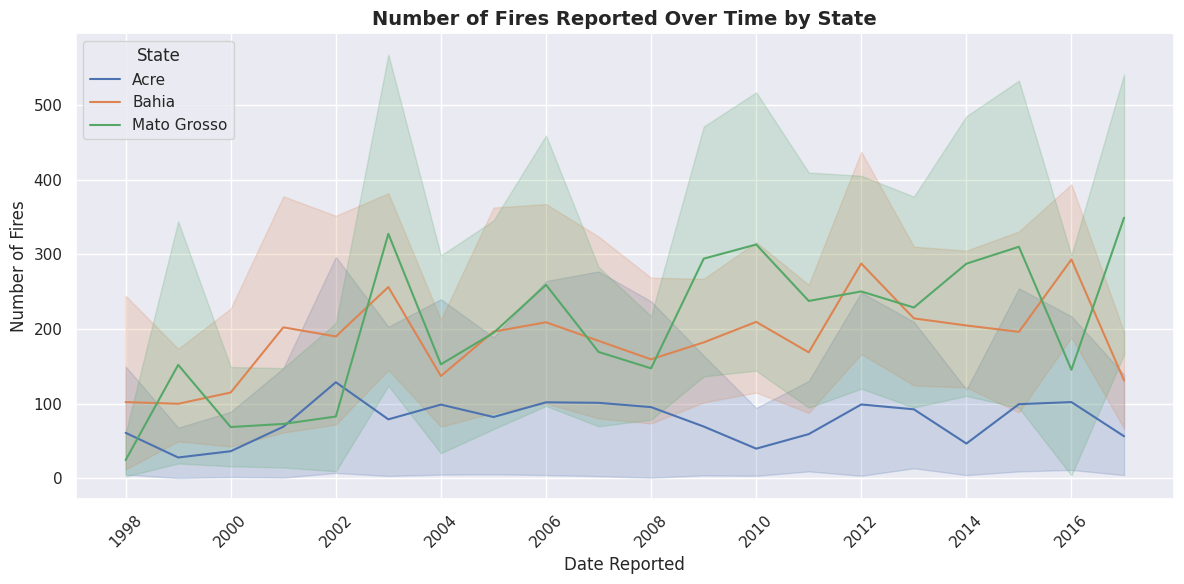

In [12]:
# 1. Set a clean visual style for the plot (optional but recommended)
sns.set_theme(style="darkgrid")

# 2. Define the figure size so the chart is wide enough to read dates clearly
plt.figure(figsize=(12, 6))

# 3. Create the seaborn line plot
sns.lineplot(
    data=df_ffire_filt, x="Date Reported", y="Number of Fires", hue="State"
)

# 4. Add titles and axis labels
plt.title(
    "Number of Fires Reported Over Time by State", fontsize=14, fontweight="bold"
)
plt.xlabel("Date Reported", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)

# 5. Rotate the x-axis date labels so they don't overlap each other
plt.xticks(rotation=45)

# 6. Adjust the layout, save, and display the plot
plt.savefig('fires.png')
plt.tight_layout()
plt.show()

## Activity 3
1. Find which state has recorded the maximum number of fires on any given day (not the total sum), and in which month did it occur?

HINT:
- Create a boolean filter based on condition on column __Number of Fires__, and
- Using this filter perform an indexing operation on the DataFrame to retrieve the corresponding records

In [13]:
# Step 1: Find the absolute maximum value in the 'Number of Fires' column
max_fires_value = df_ffire["Number of Fires"].max()

# Step 2: Create a boolean filter (a Series of True/False values)
# This checks every row to see if it equals that maximum value
max_fire_filter = df_ffire["Number of Fires"] == max_fires_value

# Step 3: Perform the indexing operation to grab the matching record(s)
highest_record = df_ffire[max_fire_filter]

# Step 4: Display the result
print(highest_record[["State", "Date Reported", "Number of Fires"]])

        State Date Reported  Number of Fires
888  Amazonas    2008-01-01            998.0


In [14]:
# same answer as above using iloc
# Extract the state and month name from our filtered record
# .iloc[0] just ensures we grab the value even if it returns as a Pandas Series
state_name = highest_record["State"].iloc[0]
month_name = highest_record["Date Reported"].dt.month_name().iloc[0]
fires_count = highest_record["Number of Fires"].iloc[0]

print(
    f"The maximum number of fires on a single day was {fires_count}."
)
print(f"This occurred in the state of {state_name} during the month of {month_name}.")

The maximum number of fires on a single day was 998.0.
This occurred in the state of Amazonas during the month of January.


In [16]:
# same answer but using idxmax
# The pro-tip way to do it in one line:
highest_record_shortcut = df_ffire.loc[df_ffire["Number of Fires"].idxmax()]
highest_record_shortcut

,888
Year,2008
State,Amazonas
Month,September
Number of Fires,998.0
Date Reported,2008-01-01 00:00:00


## Activity 4

1. Calculate the total number of fires for the entire duration (i.e. for 1998 to 2018) for every state. Save the result to a data frame called `df_group_states`.
2. Print the Summary Statistics for `df_group_states` - and what is the minimum and maximum number of total fires records?
4. Which state has recorded the minimum number of total fires, and which state has recorded the maximum number of total fires?

__HINT:__
- Use the `.groupby()` operation on the State column.
- Pandas has methods `.idxmax()` and `.idxmin()` which return the indices corresponding to the maximum and minimum values respectively, in a Pandas Series (or a Column in DataFrame).

In [20]:
# Group by State and sum the Number of Fires
df_group_states = (
    df_ffire.groupby("State")["Number of Fires"].sum().reset_index()
)

# Preview the new DataFrame
df_group_states.head()

,State,Number of Fires
0,Acre,18464.030
1,Alagoas,4644.000
2,Amapá,21831.576
3,Amazonas,30650.129
4,Bahia,44746.226


In [19]:
# to print stats
# Print the summary statistics
df_group_states.describe()

,Number of Fires
count,27.000000
mean,25886.076778
std,14260.072004
min,3237.000000
25%,15625.515000
50%,24498.000000
75%,37585.389000
max,51121.198000


In [21]:
# Find the row index for the minimum and maximum total fires
min_index = df_group_states["Number of Fires"].idxmin()
max_index = df_group_states["Number of Fires"].idxmax()

# Use .loc and the indices to grab the actual rows
min_state_record = df_group_states.loc[min_index]
max_state_record = df_group_states.loc[max_index]

# Print out the results cleanly
print(
    f"Minimum Total Fires: {min_state_record['State']} with {min_state_record['Number of Fires']:,} fires."
)
print(
    f"Maximum Total Fires: {max_state_record['State']} with {max_state_record['Number of Fires']:,} fires."
)

Minimum Total Fires: Sergipe with 3,237.0 fires.
Maximum Total Fires: São Paulo with 51,121.198 fires.


## Activity 5

1. Reset the index of the `df_group_states` DataFrame so that States are not considered as index, and are rather considered as Data Column (Hint: use method `.reset_index()` for this operation
2. Arrange the DataFrame in descending order of "Total Number of Fires".
3. Create a seaborn barplot with the State on the x-axis and the Number of Fires on the y-axis. Rotate the State labels on the x-axis so they are easier to read.



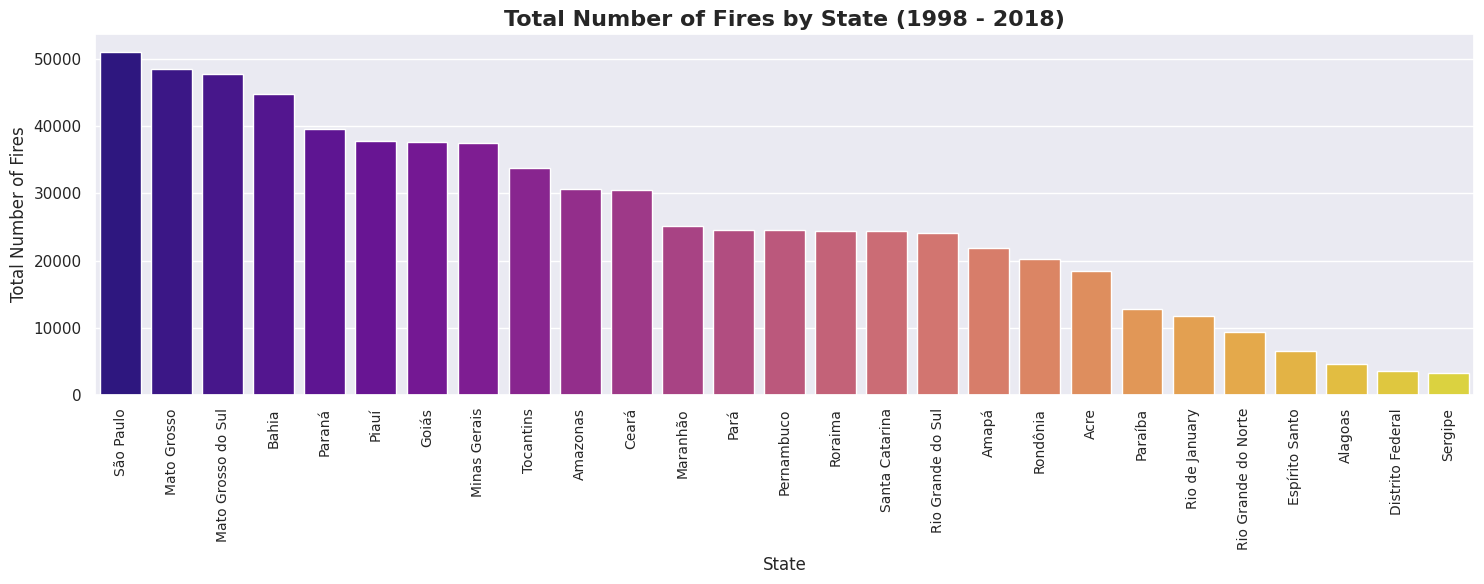

In [28]:
# 1. Reset the index so 'State' becomes a regular column
df_group_states = df_group_states.reset_index(drop=True)

# 2. Sort the DataFrame in descending order of the total fires
# 'ascending=False' ensures the state with the highest fires is at the top
df_group_states_sorted = df_group_states.sort_values(
    by="Number of Fires", ascending=False
)

# 3. Creating the plot
sns.set_theme(style="darkgrid")

# 4. Define the figure size (making it wide enough for all the states)
plt.figure(figsize=(15, 6))

# 5. Create the seaborn barplot using the sorted data
sns.barplot(
    data=df_group_states_sorted,
    x="State",
    y="Number of Fires",
    hue="State",  # 1. Assign x variable to hue to fix the warning
    palette="plasma",
    legend=False,  # 2. Set legend to False so it doesn't clutter your chart
)
# 6. Add titles and labels
plt.title(
    "Total Number of Fires by State (1998 - 2018)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Number of Fires", fontsize=12)

# 7. Rotate the State labels on the x-axis by 90 degrees so they don't overlap
plt.xticks(rotation=90, fontsize=10)

# 8. Adjust padding,save plot on a png, and display the plot
plt.savefig("brazilian_fires_by_state.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()